# Auriga VF Engine — Calibration Dataset Explorer

Quick visual audit of `datasets/calibration/`:
- Sample images with their metadata
- Capture distribution by distance, orientation, and camera height


In [1]:
import os, csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Paths relative to this notebook
CALIB_DIR  = Path("../datasets/calibration")
IMG_DIR    = CALIB_DIR / "images"
META_PATH  = CALIB_DIR / "metadata.csv"

df = pd.read_csv(META_PATH)
df["distanceMeters"]  = pd.to_numeric(df["distanceMeters"],  errors="coerce")
df["cameraHeightCm"]  = pd.to_numeric(df["cameraHeightCm"], errors="coerce")
df["capturedAt"]      = pd.to_datetime(df["capturedAt"],     errors="coerce")

print(f"Loaded {len(df)} rows")
df.head()


Loaded 16 rows


,id,filename,objectName,distanceMeters,cameraHeightCm,deviceName,orientation,notes,capturedAt,sourceType
0,8632591e-d9ee-4ff4-8326-f20d1ca6af06,8632591e-d9ee-4ff4-8326-f20d1ca6af06.jpg,aruco,1.5,50,Camera-1,Center,barely noticeable,2026-06-16 08:05:56.056000+00:00,webcam
1,a6d0ad14-ad5a-481f-b0be-fcb1e1ae82ea,a6d0ad14-ad5a-481f-b0be-fcb1e1ae82ea.jpg,aruco,1.0,50,Camera-1,Left,slightly more noticeable,2026-06-16 08:10:25.559000+00:00,webcam
2,d47f932d-706f-40e3-a86d-78c9a38f893b,d47f932d-706f-40e3-a86d-78c9a38f893b.jpg,aruco,1.0,50,Camera-1,Center,slightly more noticeable,2026-06-16 08:14:57.154000+00:00,webcam
3,f1e35e5b-305b-4679-b68d-26ae2966be6e,f1e35e5b-305b-4679-b68d-26ae2966be6e.jpg,aruco,1.0,50,Camera-1,Right,slightly more noticeable,2026-06-16 08:16:07.746000+00:00,webcam
4,47b89e24-9c9d-4455-a11e-3f18365bad7a,47b89e24-9c9d-4455-a11e-3f18365bad7a.jpg,aruco,1.5,50,Camera-1,Right,slightly more noticeable,2026-06-16 08:17:52.526000+00:00,webcam


## Dataset summary

In [2]:
print("=== Column types ===")
print(df.dtypes)
print()
print("=== Numeric stats ===")
print(df[["distanceMeters", "cameraHeightCm"]].describe())
print()
print("=== Unique values ===")
for col in ["objectName", "orientation", "deviceName", "sourceType"]:
    print(f"  {col}: {sorted(df[col].dropna().unique().tolist())}")


=== Column types ===
id                                str
filename                          str
objectName                        str
distanceMeters                float64
cameraHeightCm                  int64
deviceName                        str
orientation                       str
notes                             str
capturedAt        datetime64[us, UTC]
sourceType                        str
dtype: object

=== Numeric stats ===
       distanceMeters  cameraHeightCm
count        16.00000       16.000000
mean          1.25000       64.375000
std           0.57735       19.653244
min           0.50000       50.000000
25%           0.87500       50.000000
50%           1.25000       50.000000
75%           1.62500       70.000000
max           2.00000      100.000000

=== Unique values ===
  objectName: ['aruco']
  orientation: ['Center', 'Down', 'Left', 'Right']
  deviceName: ['Camera-1']
  sourceType: ['webcam']


## Sample images (first 8)

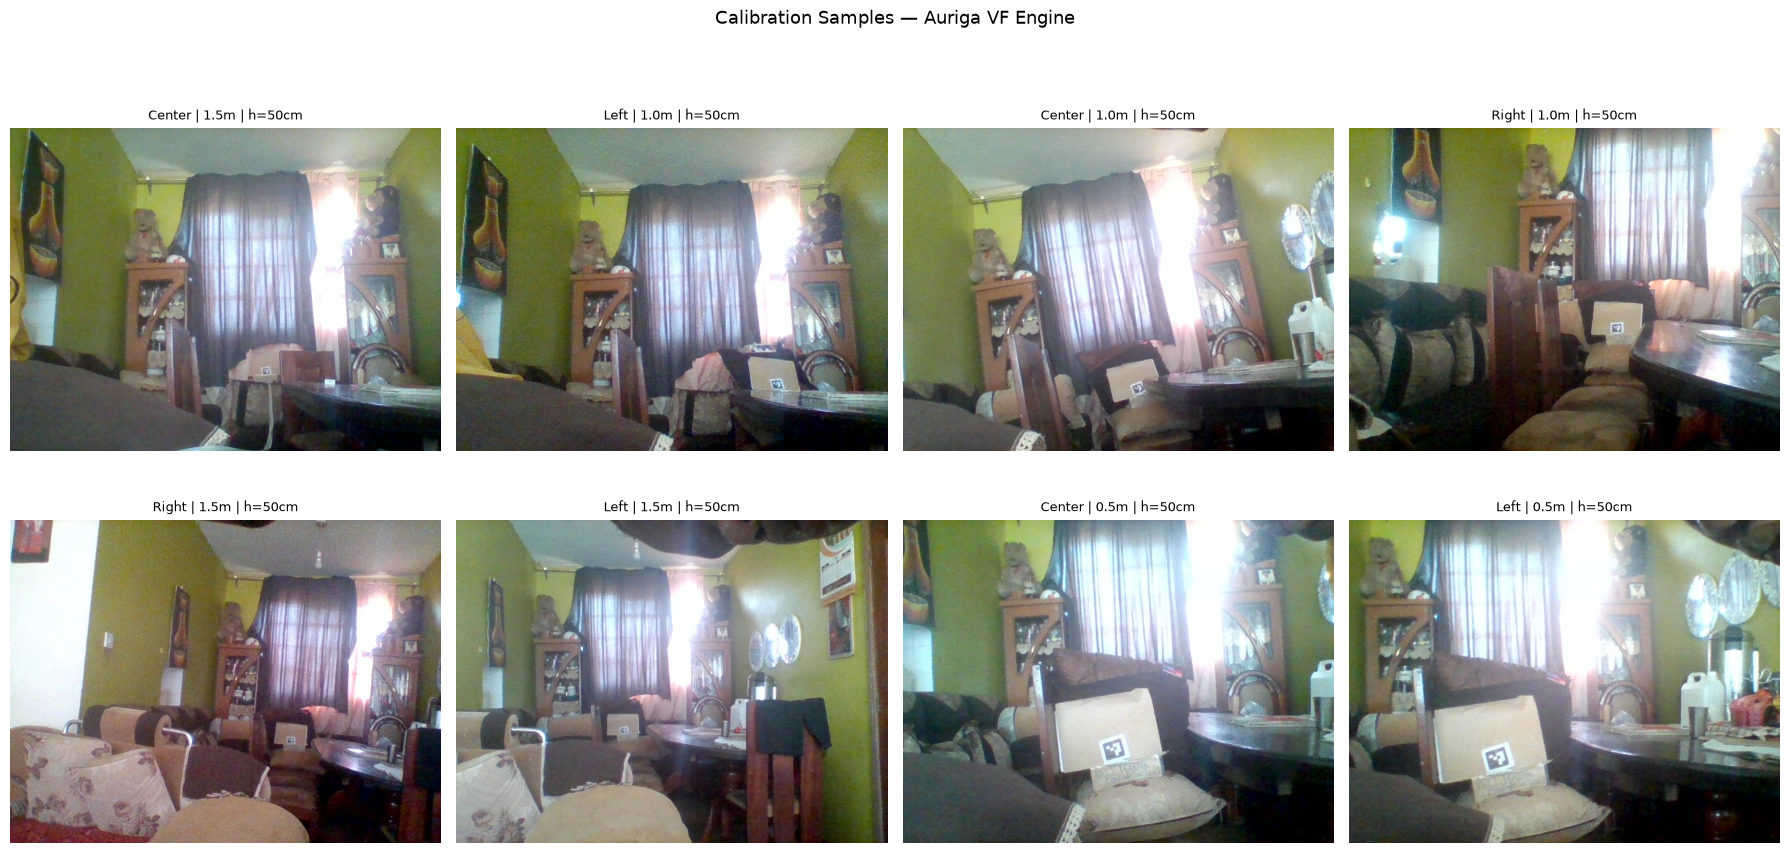

Saved → sample_grid.png


In [3]:
sample = df.head(8).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, row in sample.iterrows():
    img_path = IMG_DIR / row["filename"]
    ax = axes[i]
    if img_path.exists():
        img = mpimg.imread(str(img_path))
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "missing", ha="center", va="center",
                transform=ax.transAxes, color="red")
    ax.set_title(
        f"{row['orientation']} | {row['distanceMeters']}m | h={row['cameraHeightCm']}cm",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Calibration Samples — Auriga VF Engine", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sample_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → sample_grid.png")


## Capture distribution

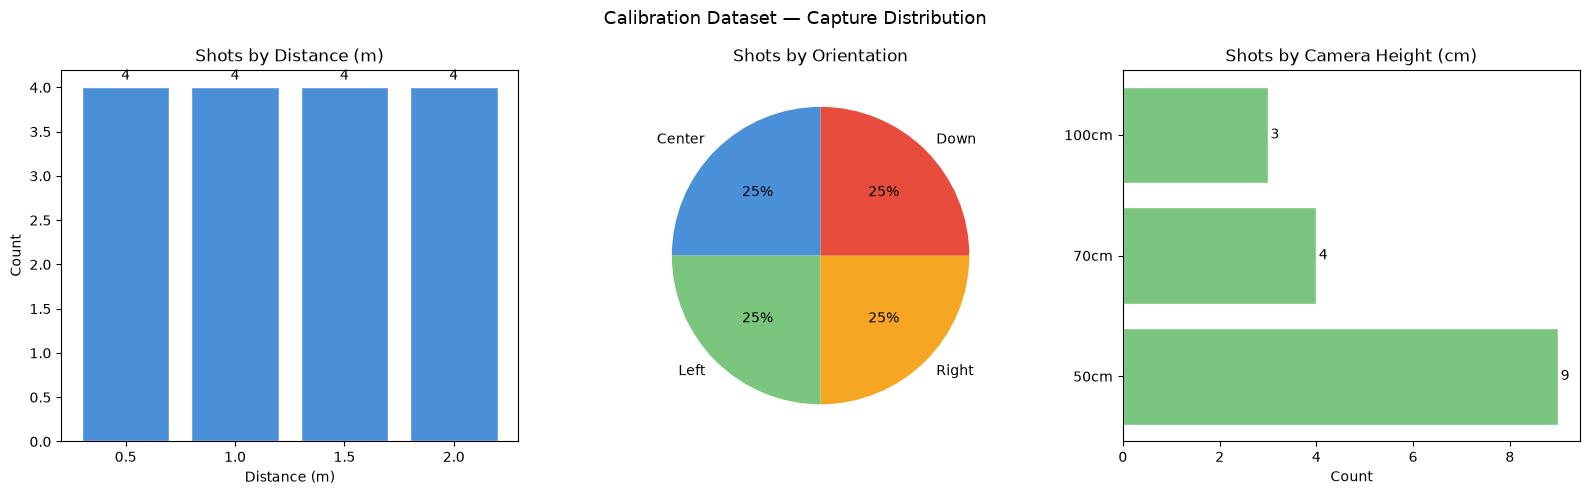

Saved → capture_distribution.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distance
dist_counts = df["distanceMeters"].value_counts().sort_index()
axes[0].bar(dist_counts.index.astype(str), dist_counts.values, color="#4A90D9", edgecolor="white")
axes[0].set_title("Shots by Distance (m)")
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, dist_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha="center", va="bottom", fontsize=10)

# Orientation
orient_counts = df["orientation"].value_counts()
axes[1].pie(orient_counts.values, labels=orient_counts.index,
            autopct="%1.0f%%", startangle=90,
            colors=["#4A90D9", "#7BC67E", "#F5A623", "#E74C3C"])
axes[1].set_title("Shots by Orientation")

# Camera height
height_counts = df["cameraHeightCm"].value_counts().sort_index()
axes[2].barh([str(h)+"cm" for h in height_counts.index], height_counts.values,
             color="#7BC67E", edgecolor="white")
axes[2].set_title("Shots by Camera Height (cm)")
axes[2].set_xlabel("Count")
for bar, val in zip(axes[2].patches, height_counts.values):
    axes[2].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=10)

plt.suptitle("Calibration Dataset — Capture Distribution", fontsize=13)
plt.tight_layout()
plt.savefig("capture_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → capture_distribution.png")


## Coverage heatmap — Orientation × Distance

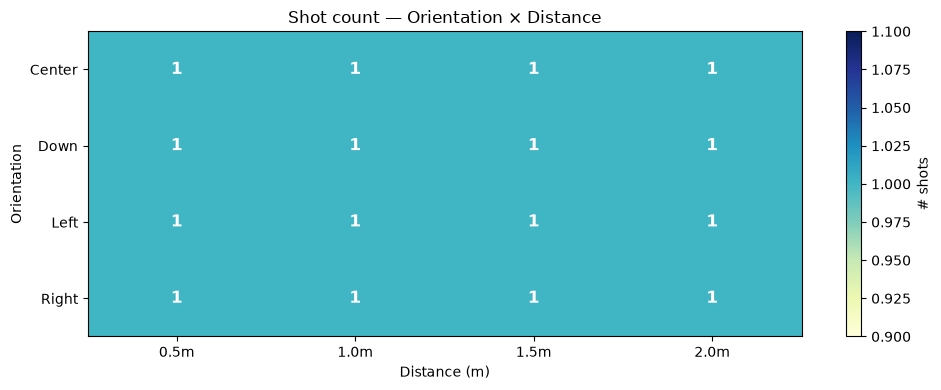

Saved → coverage_heatmap.png


In [5]:
pivot = df.pivot_table(
    index="orientation", columns="distanceMeters",
    values="id", aggfunc="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c}m" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Orientation")
ax.set_title("Shot count — Orientation × Distance")
plt.colorbar(im, ax=ax, label="# shots")

for r in range(pivot.shape[0]):
    for c in range(pivot.shape[1]):
        val = pivot.values[r, c]
        ax.text(c, r, str(val), ha="center", va="center",
                color="black" if val < pivot.values.max() * 0.7 else "white",
                fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("coverage_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → coverage_heatmap.png")


## Capture notes

In [6]:
notes = df[["id", "orientation", "distanceMeters", "notes"]].copy()
notes["notes"] = notes["notes"].fillna("(no note)")
notes.columns = ["UUID", "Orientation", "Distance (m)", "Note"]
notes["UUID"] = notes["UUID"].str[:8] + "..."
notes.style.set_caption("Field notes per capture")


,UUID,Orientation,Distance (m),Note
0,8632591e...,Center,1.500000,barely noticeable
1,a6d0ad14...,Left,1.000000,slightly more noticeable
2,d47f932d...,Center,1.000000,slightly more noticeable
3,f1e35e5b...,Right,1.000000,slightly more noticeable
4,47b89e24...,Right,1.500000,slightly more noticeable
5,f4cb4640...,Left,1.500000,slightly more noticeable
6,3f809603...,Center,0.500000,way more noticeable
7,f3445177...,Left,0.500000,way more noticeable
8,d2a93e72...,Right,0.500000,way more noticeable
9,b2454e78...,Down,0.500000,(no note)
